# DLinear Checkpoint Visualization

Load the saved DLinear checkpoint, run the Abilene test split, select target column 0, and plot both standardized-space and raw-value-space predictions.

In [11]:
from pathlib import Path
import os
import re
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CHECKPOINT = ROOT / "checkpoints" / "PMDformer" / "Datasetwater_batchsize256_ModelPMDformer_dmodel64_epochs200_patience40_SeqLen360_PredLen5_EncIn144_round_0.pt"
assert CHECKPOINT.exists(), CHECKPOINT

print("ROOT:", ROOT)
print("CWD:", Path.cwd())
print("CHECKPOINT:", CHECKPOINT)

ROOT: /home/xuke/mkw/Extreme
CWD: /home/xuke/mkw/Extreme
CHECKPOINT: /home/xuke/mkw/Extreme/checkpoints/PMDformer/Datasetwater_batchsize256_ModelPMDformer_dmodel64_epochs200_patience40_SeqLen360_PredLen5_EncIn144_round_0.pt


In [ ]:
from configs.PMDformerConfig import PMDformerConfig
from data_provider.DS_abilene import DS
from exp.exp_model_net import Model


def parse_checkpoint_config(path: Path):
    name = path.name
    patterns = {
        "bs": r"batchsize(\d+)",
        "model": r"Model([^_]+)",
        "d_model": r"dmodel(\d+)",
        "epochs": r"epochs(\d+)",
        "patience": r"patience(\d+)",
        "seq_len": r"SeqLen(\d+)",
        "pred_len": r"PredLen(\d+)",
        "enc_in": r"EncIn(\d+)",
    }
    parsed = {}
    for key, pattern in patterns.items():
        match = re.search(pattern, name)
        if match:
            value = match.group(1)
            parsed[key] = value if key == "model" else int(value)
    return parsed


device = "cuda" if torch.cuda.is_available() else "cpu"
parsed = parse_checkpoint_config(CHECKPOINT)

config = PMDformerConfig()
for key, value in parsed.items():
    setattr(config, key, value)

config.model = "PMDformer"
config.c_in = config.enc_in
config.c_out = 1
config.dec_in = 1
config.label_len = min(getattr(config, "label_len", 48), config.seq_len)
config.task_name = "long_term_forecast"
config.device = device
config.num_workers = 0
config.data_path = str(ROOT / "datasets" / "Abilene_12_12_3000_T3000_flat144.csv")
config.retrain = False
config.continue_train = False

print(parsed)
print("device:", config.device)
print("data_path:", config.data_path)
print("seq_len/pred_len/enc_in/target_col:", config.seq_len, config.pred_len, config.enc_in, config.target_col if hasattr(config, "target_col") else 0)

{'bs': 256, 'model': 'PMDformer', 'd_model': 64, 'epochs': 200, 'patience': 40, 'seq_len': 360, 'pred_len': 5, 'enc_in': 144}
device: cuda
data_path: /home/xuke/mkw/Extreme/datasets/Abilene_12_12_3000_T3000_flat144.csv
seq_len/pred_len/enc_in/target_col: 360 5 144 0


In [13]:
datamodule = DS(config)
model = Model(config).to(config.device)

state = torch.load(CHECKPOINT, map_location=config.device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]

try:
    model.load_state_dict(state, strict=True)
except RuntimeError:
    cleaned = {k.replace("_orig_mod.", "", 1): v for k, v in state.items()}
    model.load_state_dict(cleaned, strict=True)

model.eval()
print("Loaded checkpoint.")

[Tail Threshold] |value| q90=0.000081
[Raw Threshold] value q90=0.000081, q99=0.000189
[Abilene] raw shape: (3000, 144), T=3000, C=144
[Abilene] split points: train_end=2100, val_end=2400
[Abilene] raw split lengths with context: train=2100, val=660, test=960
[Abilene] windows: x_train=(1736, 360, 144), y_train=(1736, 5, 1) x_val=(296, 360, 144), y_val=(296, 5, 1) x_test=(596, 360, 144), y_test=(596, 5, 1)
[Abilene] many-to-one target: target_col=0, target_dim=1
[Abilene] value norm mean/std shape: mean=(144,), std=(144,)
Loaded checkpoint.


/tmp/ipykernel_3353511/3456865564.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CHECKPOINT, map_location=config.device)


In [14]:
preds_norm = []
labels_norm = []
sample_ids_all = []

with torch.no_grad():
    for x, x_mark, label, sample_ids in datamodule.test_data_loader:
        x = x.float().to(config.device)
        x_mark = x_mark.float().to(config.device)
        label = label.float().to(config.device)
        sample_ids = sample_ids.to(config.device).long()

        dec_input = torch.zeros_like(label[:, -config.pred_len:, :]).float()
        dec_input = torch.cat([label[:, :config.label_len, :], dec_input], dim=1)

        output = model(x, x_mark, dec_input, None)
        if isinstance(output, tuple):
            output = output[0]
        if isinstance(output, dict):
            output = output["point_pred"]

        pred_target = output[:, -config.pred_len:, config.target_col:config.target_col + 1]

        preds_norm.append(pred_target)
        labels_norm.append(label[:, -config.pred_len:, :])
        sample_ids_all.append(sample_ids)

pred_norm = torch.cat(preds_norm, dim=0).detach().cpu().numpy()
true_norm = torch.cat(labels_norm, dim=0).detach().cpu().numpy()
sample_ids_np = torch.cat(sample_ids_all, dim=0).detach().cpu().numpy()

pred_raw = datamodule.inverse_value_norm(pred_norm)
true_raw = datamodule.inverse_value_norm(true_norm)

print("standardized shapes:", pred_norm.shape, true_norm.shape)
print("raw shapes:", pred_raw.shape, true_raw.shape)
print("standardized true min/max/mean:", true_norm.min(), true_norm.max(), true_norm.mean())
print("standardized pred min/max/mean:", pred_norm.min(), pred_norm.max(), pred_norm.mean())
print("raw true min/max/mean:", true_raw.min(), true_raw.max(), true_raw.mean())
print("raw pred min/max/mean:", pred_raw.min(), pred_raw.max(), pred_raw.mean())

standardized shapes: (596, 5, 1) (596, 5, 1)
raw shapes: (596, 5, 1) (596, 5, 1)
standardized true min/max/mean: -0.7619936 6.3480515 -0.3286363
standardized pred min/max/mean: -2.047255 4.2725573 -0.26801762
raw true min/max/mean: 0.0 0.00034871168 2.1253978e-05
raw pred min/max/mean: -6.303556e-05 0.0002469192 2.4227018e-05


In [15]:
def aggregate_by_time(true_values, pred_values, sample_ids, seq_len):
    true_values = np.asarray(true_values)
    pred_values = np.asarray(pred_values)
    sample_ids = np.asarray(sample_ids).astype(np.int64)

    n_windows, pred_len, out_dim = true_values.shape
    true_sum = {}
    pred_sum = {}
    count = {}

    for window_idx, start in enumerate(sample_ids):
        base = int(start) + int(seq_len)
        for horizon in range(pred_len):
            time_idx = base + horizon
            if time_idx not in count:
                true_sum[time_idx] = np.zeros(out_dim, dtype=np.float64)
                pred_sum[time_idx] = np.zeros(out_dim, dtype=np.float64)
                count[time_idx] = 0
            true_sum[time_idx] += true_values[window_idx, horizon]
            pred_sum[time_idx] += pred_values[window_idx, horizon]
            count[time_idx] += 1

    rows = []
    for time_idx in sorted(count):
        rows.append({
            "time_idx": time_idx,
            "count": count[time_idx],
            "true": true_sum[time_idx][0] / count[time_idx],
            "pred": pred_sum[time_idx][0] / count[time_idx],
        })
    return pd.DataFrame(rows)


window_norm_df = pd.DataFrame({
    "index": np.arange(true_norm.reshape(-1).shape[0]),
    "true": true_norm.reshape(-1),
    "pred": pred_norm.reshape(-1),
})
window_raw_df = pd.DataFrame({
    "index": np.arange(true_raw.reshape(-1).shape[0]),
    "true": true_raw.reshape(-1),
    "pred": pred_raw.reshape(-1),
})

agg_norm_df = aggregate_by_time(true_norm, pred_norm, sample_ids_np, config.seq_len)
agg_raw_df = aggregate_by_time(true_raw, pred_raw, sample_ids_np, config.seq_len)

for name, df in [("standardized", window_norm_df), ("raw", window_raw_df)]:
    mae = np.mean(np.abs(df["pred"].to_numpy() - df["true"].to_numpy()))
    rmse = np.sqrt(np.mean((df["pred"].to_numpy() - df["true"].to_numpy()) ** 2))
    print(f"{name} MAE={mae:.8g}, RMSE={rmse:.8g}")

print("window rows:", len(window_raw_df))
print("aggregated rows:", len(agg_raw_df))
display(window_norm_df.head())
display(window_raw_df.head())
display(agg_raw_df.head())

standardized MAE=0.44592556, RMSE=0.77726412
raw MAE=2.187039e-05, RMSE=3.8120863e-05
window rows: 2980
aggregated rows: 600


,index,true,pred
0,0,-0.761994,0.560753
1,1,-0.761994,0.463456
2,2,-0.761994,0.404942
3,3,-0.078919,0.366505
4,4,-0.761994,0.103014


,index,true,pred
0,0,0.000000,0.000065
1,1,0.000000,0.000060
2,2,0.000000,0.000057
3,3,0.000034,0.000055
4,4,0.000000,0.000042


,time_idx,count,true,pred
0,2400,1,0.000000,0.000065
1,2401,2,0.000000,0.000058
2,2402,3,0.000000,0.000054
3,2403,4,0.000034,0.000048
4,2404,5,0.000000,0.000043


plot style: seaborn-v0_8-whitegrid


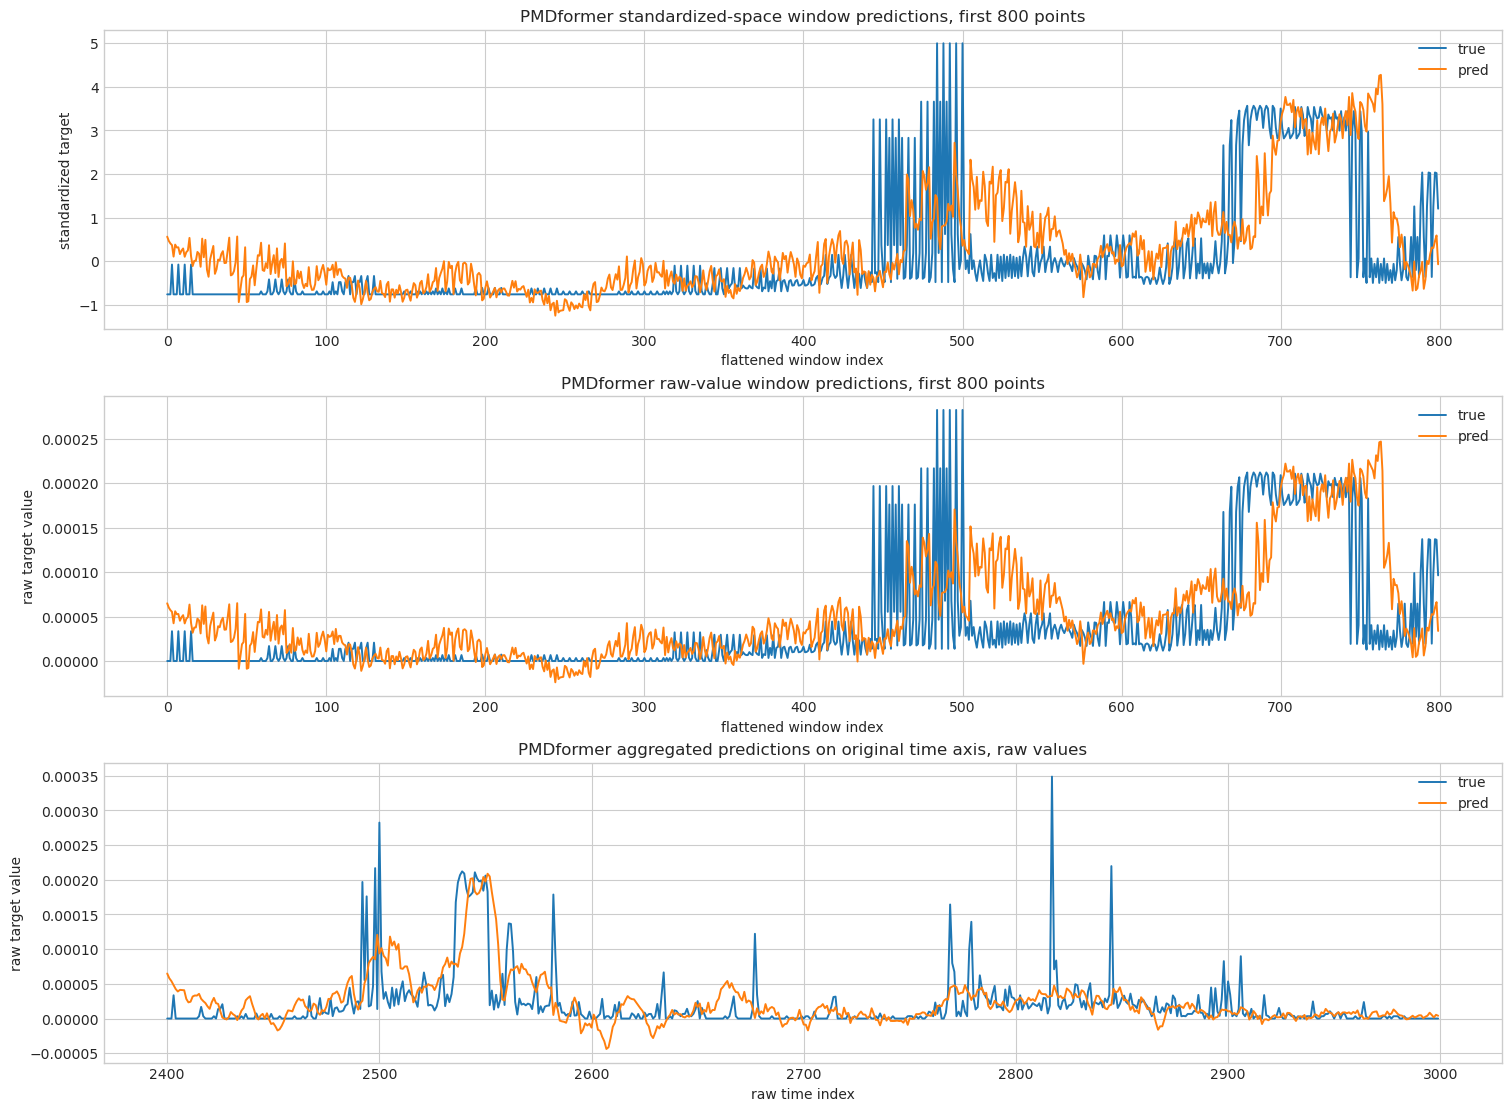

In [16]:
for style_name in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot", "default"]:
    if style_name in plt.style.available or style_name == "default":
        plt.style.use(style_name)
        print("plot style:", style_name)
        break

max_points = min(800, len(window_raw_df))
fig, axes = plt.subplots(3, 1, figsize=(15, 11), constrained_layout=True)

axes[0].plot(window_norm_df["index"].iloc[:max_points], window_norm_df["true"].iloc[:max_points], label="true", linewidth=1.4)
axes[0].plot(window_norm_df["index"].iloc[:max_points], window_norm_df["pred"].iloc[:max_points], label="pred", linewidth=1.4)
axes[0].set_title(f"PMDformer standardized-space window predictions, first {max_points} points")
axes[0].set_xlabel("flattened window index")
axes[0].set_ylabel("standardized target")
axes[0].legend()

axes[1].plot(window_raw_df["index"].iloc[:max_points], window_raw_df["true"].iloc[:max_points], label="true", linewidth=1.4)
axes[1].plot(window_raw_df["index"].iloc[:max_points], window_raw_df["pred"].iloc[:max_points], label="pred", linewidth=1.4)
axes[1].set_title(f"PMDformer raw-value window predictions, first {max_points} points")
axes[1].set_xlabel("flattened window index")
axes[1].set_ylabel("raw target value")
axes[1].legend()

axes[2].plot(agg_raw_df["time_idx"], agg_raw_df["true"], label="true", linewidth=1.4)
axes[2].plot(agg_raw_df["time_idx"], agg_raw_df["pred"], label="pred", linewidth=1.4)
axes[2].set_title("PMDformer aggregated predictions on original time axis, raw values")
axes[2].set_xlabel("raw time index")
axes[2].set_ylabel("raw target value")
axes[2].legend()

plt.show()

In [17]:
OUT_DIR = ROOT / "draw"
OUT_DIR.mkdir(exist_ok=True)

window_norm_path = OUT_DIR / "checkpoint_DLinear_PL5_window_standardized.csv"
window_raw_path = OUT_DIR / "checkpoint_DLinear_PL5_window_raw.csv"
agg_raw_path = OUT_DIR / "checkpoint_DLinear_PL5_agg_raw.csv"

window_norm_df.to_csv(window_norm_path, index=False)
window_raw_df.to_csv(window_raw_path, index=False)
agg_raw_df.to_csv(agg_raw_path, index=False)

print("saved:", window_norm_path)
print("saved:", window_raw_path)
print("saved:", agg_raw_path)

saved: /home/xuke/mkw/Extreme/draw/checkpoint_DLinear_PL5_window_standardized.csv
saved: /home/xuke/mkw/Extreme/draw/checkpoint_DLinear_PL5_window_raw.csv
saved: /home/xuke/mkw/Extreme/draw/checkpoint_DLinear_PL5_agg_raw.csv
